# 🎬 Netflix Data Exploration & Visualization — Business Case Study

**Author:** Pritam Palit

**Objective:** Analyze Netflix's content catalog to derive actionable insights
that inform content production strategy, market expansion, and launch timing.

---

## Table of Contents

1. [Problem Statement & Basic Metrics](#1)
2. [Non-Graphical Analysis](#2)
3. [Data Preprocessing](#3)
4. [Visual Analysis](#4)
   - 4.1 Univariate Analysis
   - 4.2 Bivariate Analysis & Boxplots
5. [Missing Value & Outlier Check](#5)
6. [Insights](#6)
7. [Business Insights](#7)
8. [Recommendations](#8)

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# Plotting defaults
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

NETFLIX_RED = "#E50914"
NETFLIX_BLACK = "#141414"
PALETTE = ["#E50914", "#564d4d", "#831010", "#B20710", "#221f1f"]

# Paths
IMG_DIR = 'images'
DATA_PATH = os.path.join('data', 'netflix.csv')

os.makedirs(IMG_DIR, exist_ok=True)

def save_fig(fig, name):
    """Save figure to IMG_DIR and display it."""
    fig.savefig(os.path.join(IMG_DIR, name), bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

print("✅ Setup complete.")

✅ Setup complete.


---
<a id="1"></a>
## 1. Problem Statement & Basic Metrics (10 pts)

### Problem Statement

Netflix, the world's leading streaming platform, needs **data-driven guidance**
to answer these strategic questions:

1. **What type of content** (Movies vs TV Shows) should Netflix prioritize producing?
2. **Which countries** represent the best growth opportunities?
3. **What genres** resonate most with global audiences?
4. **When** is the optimal time to release new content?
5. How has Netflix's **content strategy evolved** over the years?

We will explore a dataset of **8,800+ titles** available on Netflix to surface
patterns, trends, and actionable recommendations.

In [2]:
# ── 1.1 Load the dataset ────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
df.head()

Dataset loaded: 8,807 rows × 12 columns



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# ── 1.2 Shape & Data Types ──────────────────────────────────────────────
print("Shape:", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)

Shape: (8807, 12)

Column Data Types:
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


In [4]:
# ── 1.3 Missing Values ──────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with Missing Values:\n")
print(missing_df.to_string())

Columns with Missing Values:

            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


In [5]:
# ── 1.4 Statistical Summary ─────────────────────────────────────────────
print("Statistical Summary (Numerical):\n")
df.describe()

Statistical Summary (Numerical):



,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
print("\nStatistical Summary (Categorical):\n")
df.describe(include="object")


Statistical Summary (Categorical):



,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


---
<a id="2"></a>
## 2. Non-Graphical Analysis (10 pts)

Before any visualization, let's look at value counts and unique attributes
to build an intuition of the data.

In [7]:
# ── 2.1 Content Type Distribution ───────────────────────────────────────
print("Content Type Value Counts:\n")
print(df["type"].value_counts())
print(f"\nMovie-to-TV-Show Ratio: {df['type'].value_counts().iloc[0] / df['type'].value_counts().iloc[1]:.2f} : 1")

Content Type Value Counts:

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Movie-to-TV-Show Ratio: 2.29 : 1


In [8]:
# ── 2.2 Rating Distribution ─────────────────────────────────────────────
print("Rating Value Counts:\n")
print(df["rating"].value_counts())

Rating Value Counts:

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [9]:
# ── 2.3 Top Genres (listed_in) ───────────────────────────────────────────
# Each title can belong to multiple genres; we split them out
all_genres = df["listed_in"].dropna().str.split(", ").explode().str.strip()
print("Top 20 Genres:\n")
print(all_genres.value_counts().head(20))

Top 20 Genres:



listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Music & Musicals             375
Romantic TV Shows            370
Horror Movies                357
Stand-Up Comedy              343
Reality TV                   255
Name: count, dtype: int64


In [10]:
# ── 2.4 Top Countries ───────────────────────────────────────────────────
all_countries = df["country"].dropna().str.split(", ").explode().str.strip()
print("Top 20 Countries:\n")
print(all_countries.value_counts().head(20))

Top 20 Countries:

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Nigeria            103
Italy              100
Brazil              97
Argentina           91
Belgium             90
Name: count, dtype: int64


In [11]:
# ── 2.5 Unique Attribute Summary ────────────────────────────────────────
print("Unique Values per Column:\n")
for col in df.columns:
    print(f"  {col:15s} → {df[col].nunique():>6,} unique values")

Unique Values per Column:

  show_id         →  8,807 unique values
  type            →      2 unique values
  title           →  8,807 unique values
  director        →  4,528 unique values
  cast            →  7,692 unique values
  country         →    748 unique values
  date_added      →  1,767 unique values
  release_year    →     74 unique values
  rating          →     17 unique values
  duration        →    220 unique values
  listed_in       →    514 unique values
  description     →  8,775 unique values


---
<a id="3"></a>
## 3. Data Preprocessing

Key preprocessing steps:
- Parse `date_added` to datetime and extract `year_added`, `month_added`
- Handle missing values
- Create helper columns for unnested multi-value fields

In [12]:
# ── 3.1 Parse date_added ────────────────────────────────────────────────
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), format="mixed", errors="coerce")
df["year_added"] = df["date_added"].dt.year.astype("Int64")
df["month_added"] = df["date_added"].dt.month.astype("Int64")
df["month_name"] = df["date_added"].dt.month_name()

print("date_added parsed. Sample:")
df[["title", "date_added", "year_added", "month_added"]].head()

date_added parsed. Sample:

,title,date_added,year_added,month_added
0,Dick Johnson Is Dead,2021-09-25,2021,9
1,Blood & Water,2021-09-24,2021,9
2,Ganglands,2021-09-24,2021,9
3,Jailbirds New Orleans,2021-09-24,2021,9
4,Kota Factory,2021-09-24,2021,9


In [13]:
# ── 3.2 Handle Missing Values ───────────────────────────────────────────
fill_map = {
    "director": "Unknown",
    "cast": "Unknown",
    "country": "Unknown",
    "rating": "Unrated",
}
for col, val in fill_map.items():
    df[col] = df[col].fillna(val)

print("Missing values after imputation:\n")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("  (No missing values remain in key columns)")

Missing values after imputation:

date_added     10
duration        3
year_added     10
month_added    10
month_name     10
dtype: int64


In [14]:
# ── 3.3 Parse duration ──────────────────────────────────────────────────
df["duration_int"] = df["duration"].str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].str.extract(r"(min|Season)")

print("Duration parsed. Sample:")
df[["title", "type", "duration", "duration_int", "duration_unit"]].head(10)

Duration parsed. Sample:


,title,type,duration,duration_int,duration_unit
0,Dick Johnson Is Dead,Movie,90 min,90.0,min
1,Blood & Water,TV Show,2 Seasons,2.0,Season
2,Ganglands,TV Show,1 Season,1.0,Season
3,Jailbirds New Orleans,TV Show,1 Season,1.0,Season
4,Kota Factory,TV Show,2 Seasons,2.0,Season
5,Midnight Mass,TV Show,1 Season,1.0,Season
6,My Little Pony: A New Generation,Movie,91 min,91.0,min
7,Sankofa,Movie,125 min,125.0,min
8,The Great British Baking Show,TV Show,9 Seasons,9.0,Season
9,The Starling,Movie,104 min,104.0,min


In [15]:
# ── 3.4 Unnest multi-value columns ──────────────────────────────────────
# Create exploded DataFrames for analysis
df_genres = df[["show_id", "type", "listed_in"]].copy()
df_genres = df_genres.assign(genre=df_genres["listed_in"].str.split(", ")).explode("genre")
df_genres["genre"] = df_genres["genre"].str.strip()

df_countries = df[["show_id", "type", "country"]].copy()
df_countries = df_countries.assign(country_single=df_countries["country"].str.split(", ")).explode("country_single")
df_countries["country_single"] = df_countries["country_single"].str.strip()

df_cast = df[["show_id", "type", "cast"]].copy()
df_cast = df_cast.assign(actor=df_cast["cast"].str.split(", ")).explode("actor")
df_cast["actor"] = df_cast["actor"].str.strip()

df_directors = df[["show_id", "type", "director"]].copy()
df_directors = df_directors.assign(dir_name=df_directors["director"].str.split(", ")).explode("dir_name")
df_directors["dir_name"] = df_directors["dir_name"].str.strip()

print(f"Exploded genres    : {len(df_genres):,} rows")
print(f"Exploded countries : {len(df_countries):,} rows")
print(f"Exploded cast      : {len(df_cast):,} rows")
print(f"Exploded directors : {len(df_directors):,} rows")

Exploded genres    : 19,323 rows
Exploded countries : 10,845 rows
Exploded cast      : 64,951 rows
Exploded directors : 9,612 rows


In [16]:
print("\nPreprocessed DataFrame Info:")
df.info()


Preprocessed DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   str           
 1   type           8807 non-null   str           
 2   title          8807 non-null   str           
 3   director       8807 non-null   str           
 4   cast           8807 non-null   str           
 5   country        8807 non-null   str           
 6   date_added     8797 non-null   datetime64[us]
 7   release_year   8807 non-null   int64         
 8   rating         8807 non-null   str           
 9   duration       8804 non-null   str           
 10  listed_in      8807 non-null   str           
 11  description    8807 non-null   str           
 12  year_added     8797 non-null   Int64         
 13  month_added    8797 non-null   Int64         
 14  month_name     8797 non-null   str           
 15  du

---
<a id="4"></a>
## 4. Visual Analysis (20 pts)

### 4.1 Univariate Analysis (10 pts)

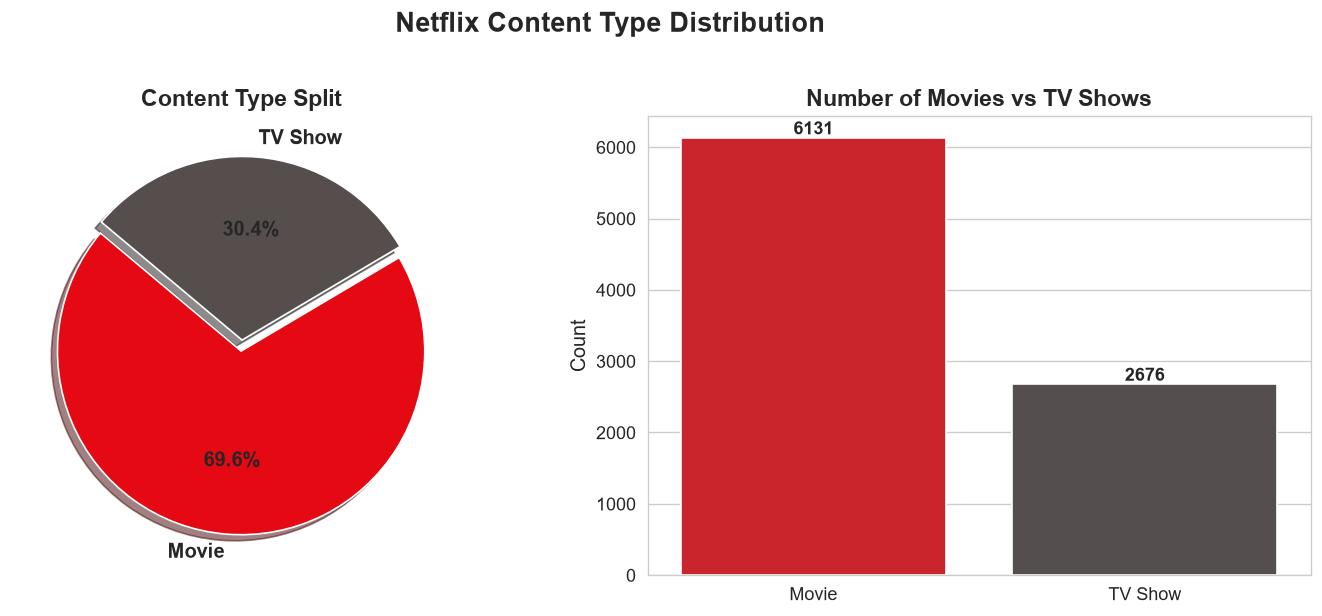

In [17]:
# ── 4.1.1 Content Type Distribution (Movie vs TV Show) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
type_counts = df["type"].value_counts()
colors_pie = [NETFLIX_RED, "#564d4d"]
axes[0].pie(
    type_counts, labels=type_counts.index, autopct="%1.1f%%",
    colors=colors_pie, startangle=140, textprops={"fontsize": 12, "fontweight": "bold"},
    explode=(0.03, 0.03), shadow=True,
)
axes[0].set_title("Content Type Split", fontweight="bold")

# Bar chart
sns.barplot(x=type_counts.index, y=type_counts.values, palette=colors_pie, ax=axes[1])
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 50, str(v), ha="center", fontweight="bold")
axes[1].set_title("Number of Movies vs TV Shows", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("")

fig.suptitle("Netflix Content Type Distribution", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "01_content_type_distribution.png")

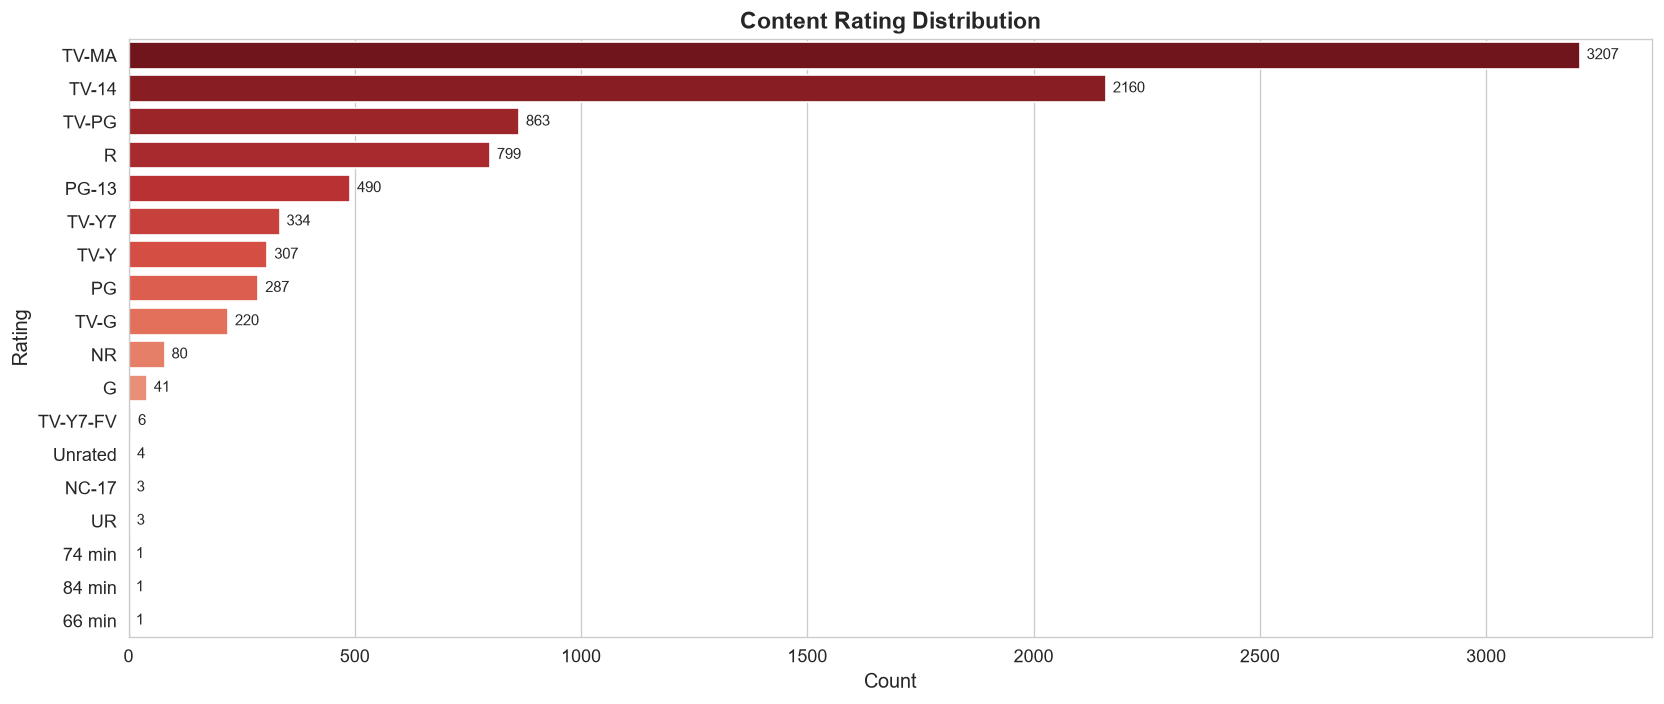

In [18]:
# ── 4.1.2 Rating Distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
rating_order = df["rating"].value_counts().index
sns.countplot(data=df, y="rating", order=rating_order, palette="Reds_r", ax=ax)
ax.set_title("Content Rating Distribution", fontweight="bold")
ax.set_xlabel("Count")
ax.set_ylabel("Rating")
for p in ax.patches:
    ax.text(p.get_width() + 15, p.get_y() + p.get_height() / 2,
            f"{int(p.get_width())}", va="center", fontsize=9)
fig.tight_layout()
save_fig(fig, "02_rating_distribution.png")

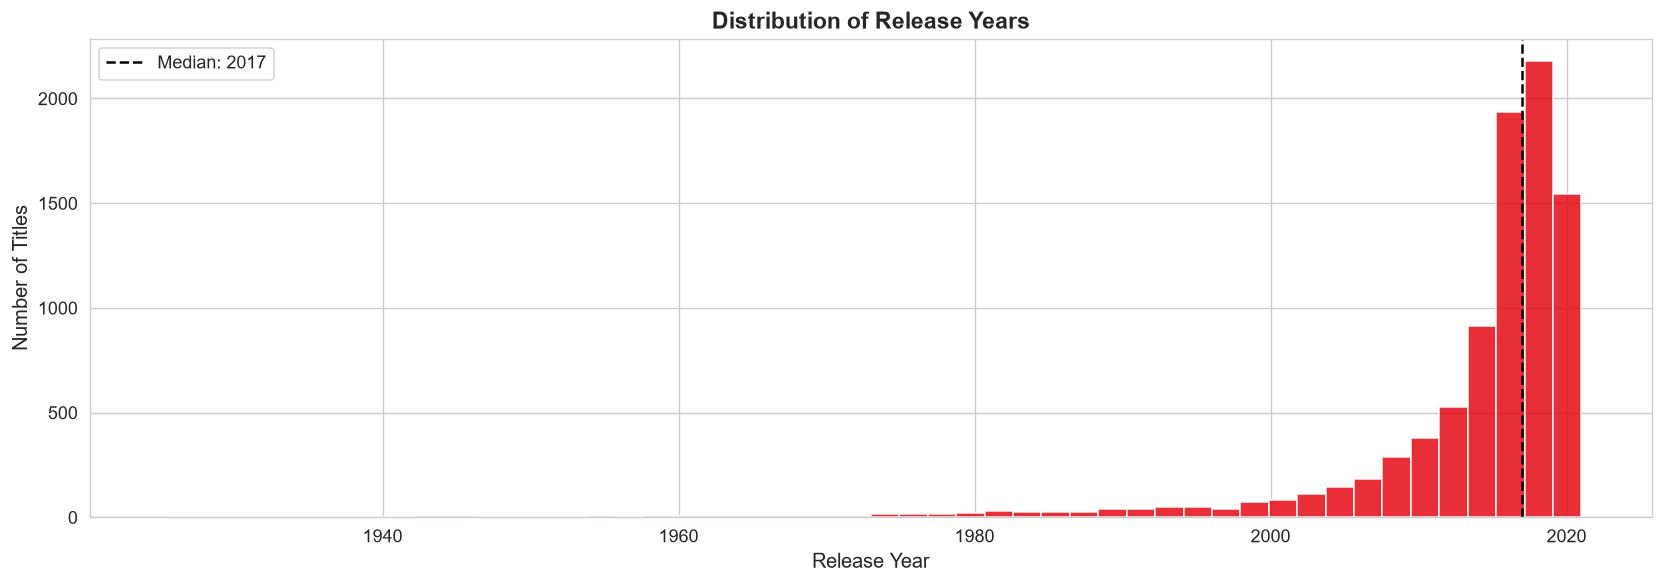

In [19]:
# ── 4.1.3 Release Year Histogram ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df["release_year"].dropna(), bins=50, color=NETFLIX_RED, edgecolor="white", alpha=0.85)
ax.set_title("Distribution of Release Years", fontweight="bold")
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Titles")
ax.axvline(df["release_year"].median(), color="black", linestyle="--", label=f"Median: {int(df['release_year'].median())}")
ax.legend()
fig.tight_layout()
save_fig(fig, "03_release_year_histogram.png")

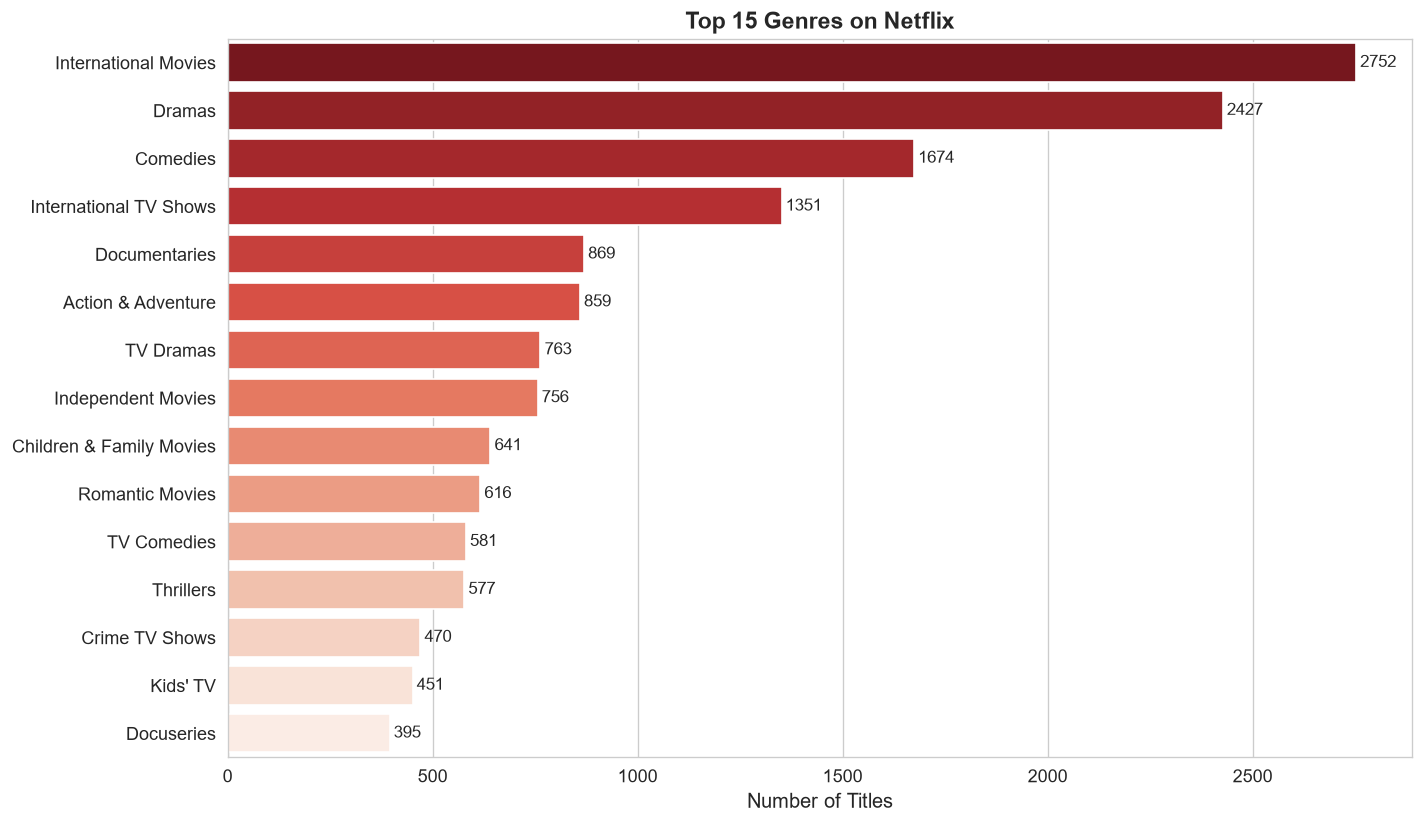

In [20]:
# ── 4.1.4 Top 15 Genres ─────────────────────────────────────────────────
top_genres = df_genres["genre"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="Reds_r", ax=ax)
ax.set_title("Top 15 Genres on Netflix", fontweight="bold")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("")
for i, v in enumerate(top_genres.values):
    ax.text(v + 10, i, str(v), va="center", fontsize=10)
fig.tight_layout()
save_fig(fig, "04_top15_genres.png")

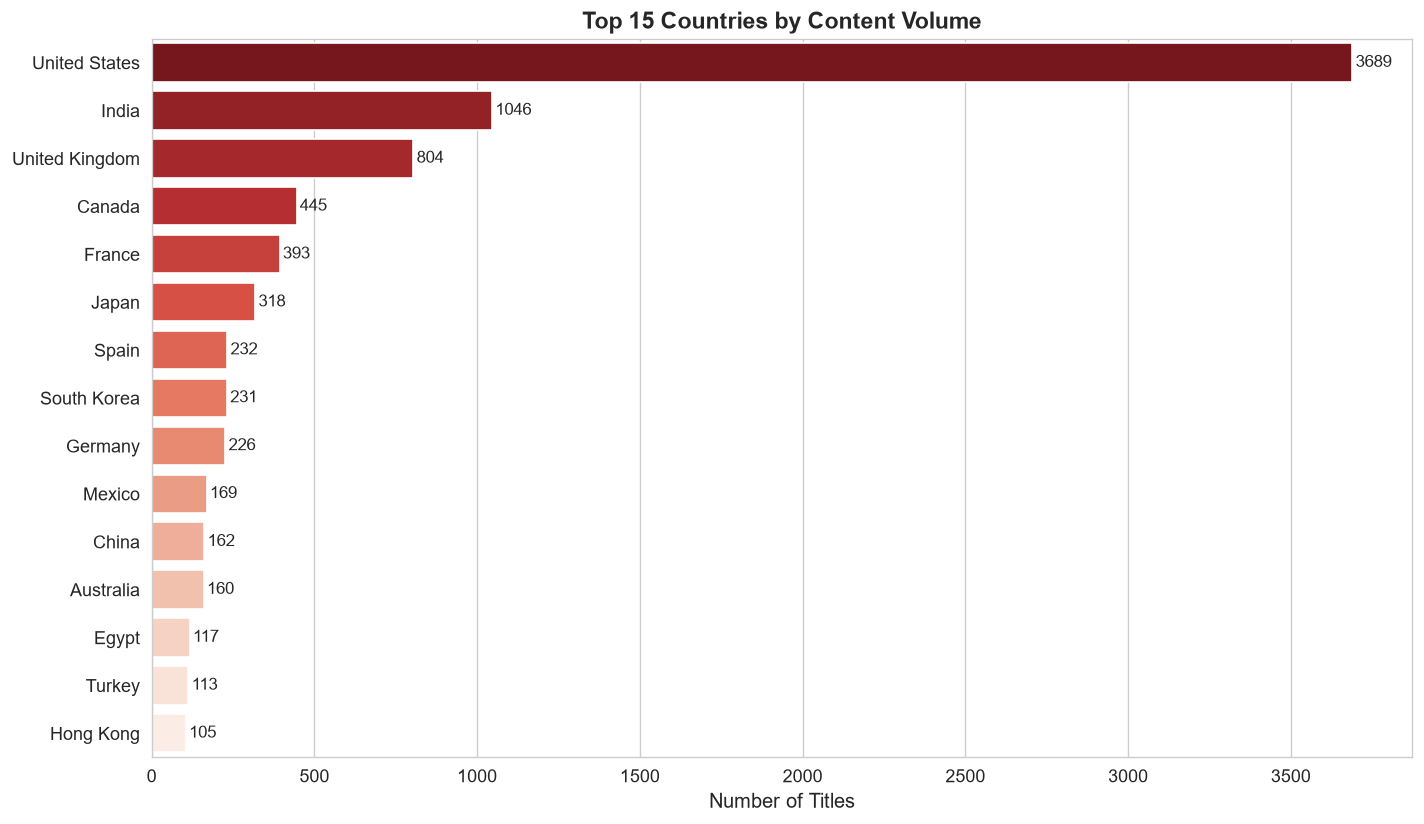

In [21]:
# ── 4.1.5 Top 15 Countries ──────────────────────────────────────────────
top_countries = df_countries[df_countries["country_single"] != "Unknown"]["country_single"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="Reds_r", ax=ax)
ax.set_title("Top 15 Countries by Content Volume", fontweight="bold")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("")
for i, v in enumerate(top_countries.values):
    ax.text(v + 10, i, str(v), va="center", fontsize=10)
fig.tight_layout()
save_fig(fig, "05_top15_countries.png")

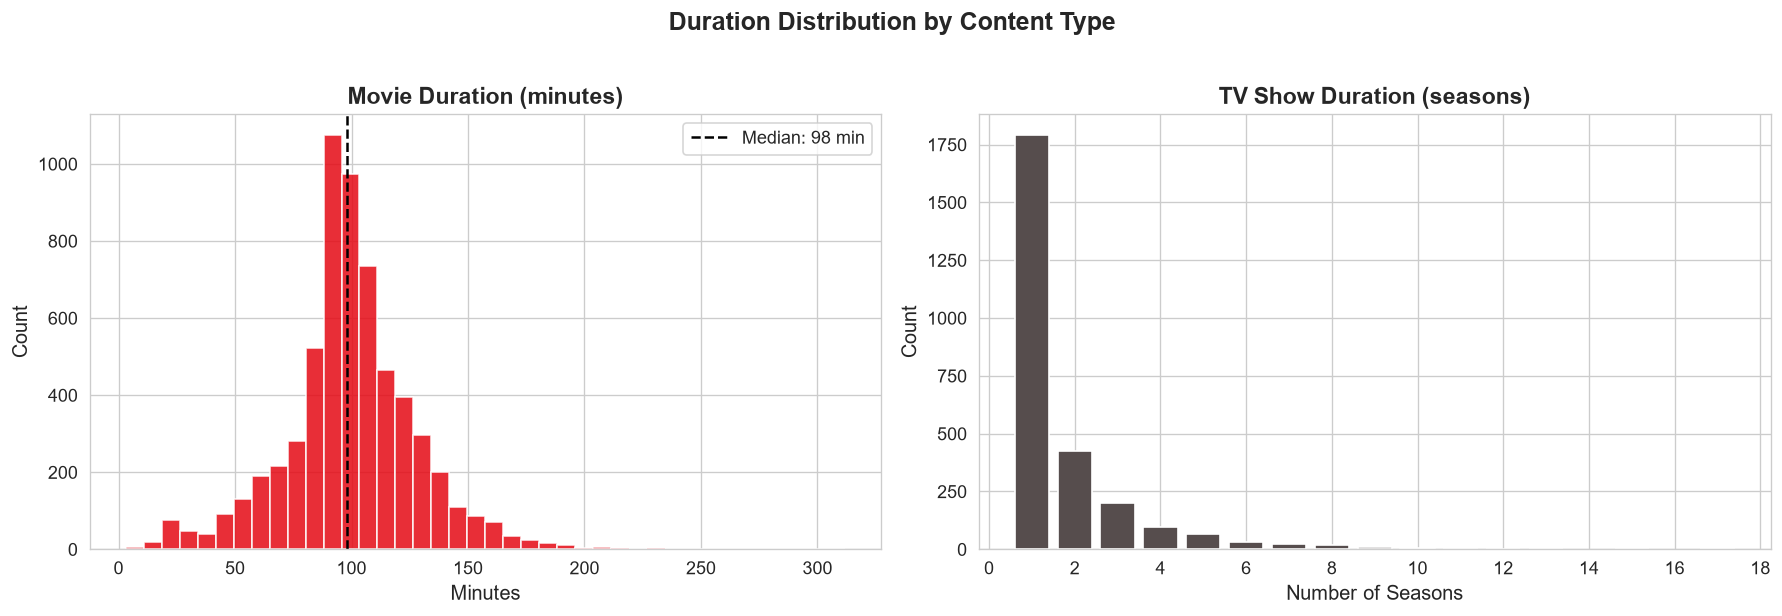

In [22]:
# ── 4.1.6 Duration Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Movies — duration in minutes
movies = df[(df["type"] == "Movie") & (df["duration_int"].notna())]
axes[0].hist(movies["duration_int"], bins=40, color=NETFLIX_RED, edgecolor="white", alpha=0.85)
axes[0].set_title("Movie Duration (minutes)", fontweight="bold")
axes[0].set_xlabel("Minutes")
axes[0].set_ylabel("Count")
axes[0].axvline(movies["duration_int"].median(), color="black", linestyle="--",
                label=f"Median: {movies['duration_int'].median():.0f} min")
axes[0].legend()

# TV Shows — duration in seasons
tv = df[(df["type"] == "TV Show") & (df["duration_int"].notna())]
season_counts = tv["duration_int"].value_counts().sort_index()
axes[1].bar(season_counts.index.astype(int), season_counts.values, color="#564d4d", edgecolor="white")
axes[1].set_title("TV Show Duration (seasons)", fontweight="bold")
axes[1].set_xlabel("Number of Seasons")
axes[1].set_ylabel("Count")
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.suptitle("Duration Distribution by Content Type", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "06_duration_distribution.png")

### 4.2 Bivariate Analysis & Boxplots (10 pts)

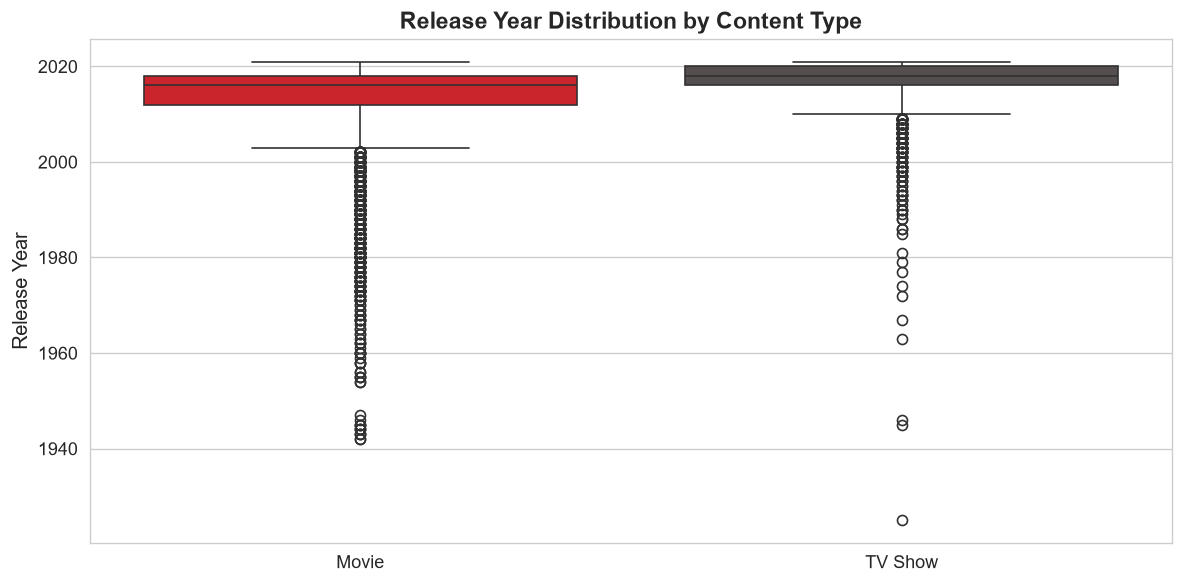

In [23]:
# ── 4.2.1 Release Year by Type (Boxplot) ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="type", y="release_year", palette=[NETFLIX_RED, "#564d4d"], ax=ax)
ax.set_title("Release Year Distribution by Content Type", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Release Year")
fig.tight_layout()
save_fig(fig, "07_release_year_by_type_boxplot.png")

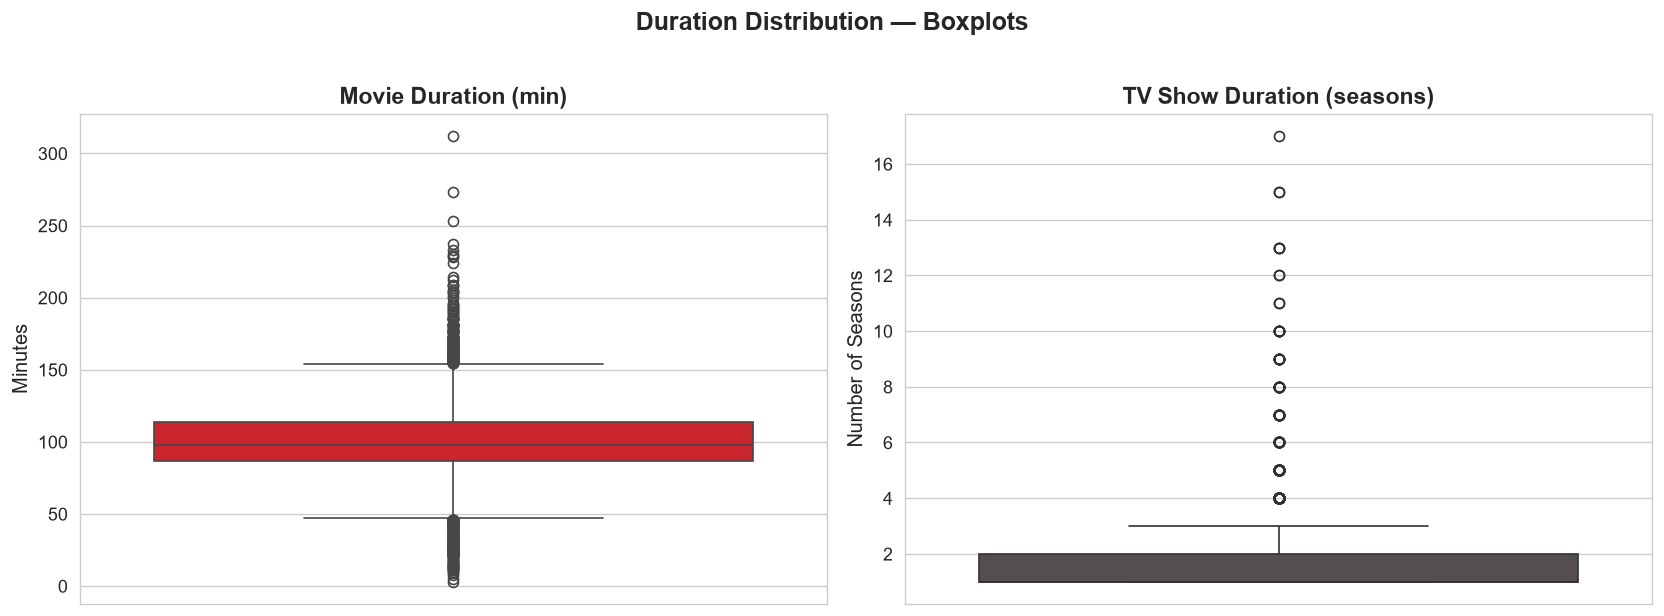

In [24]:
# ── 4.2.2 Duration by Type (Boxplot) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=movies, y="duration_int", color=NETFLIX_RED, ax=axes[0])
axes[0].set_title("Movie Duration (min)", fontweight="bold")
axes[0].set_ylabel("Minutes")

sns.boxplot(data=tv, y="duration_int", color="#564d4d", ax=axes[1])
axes[1].set_title("TV Show Duration (seasons)", fontweight="bold")
axes[1].set_ylabel("Number of Seasons")

fig.suptitle("Duration Distribution — Boxplots", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "08_duration_by_type_boxplot.png")

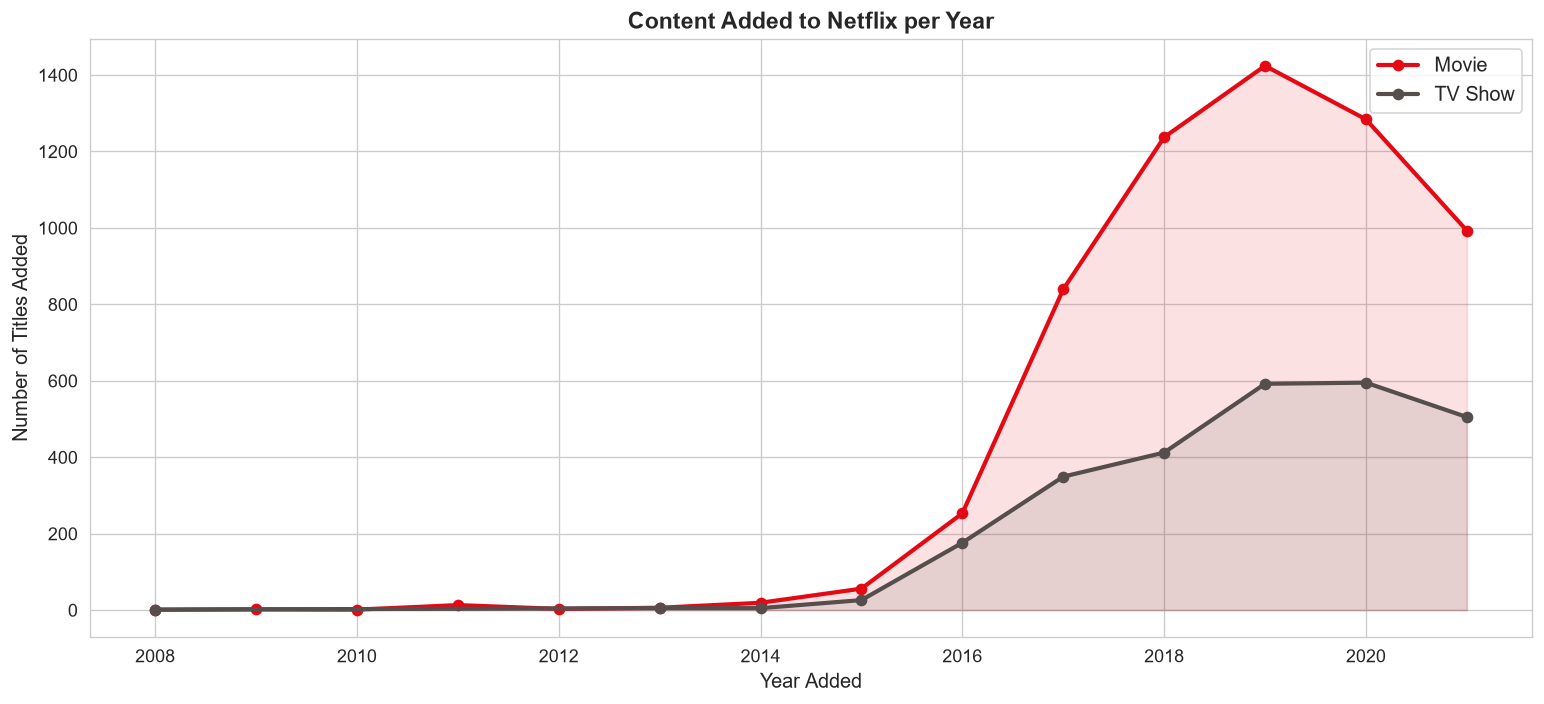

In [25]:
# ── 4.2.3 Content Added per Year — Trend Line ───────────────────────────
yearly = df.groupby(["year_added", "type"]).size().reset_index(name="count")
yearly = yearly.dropna(subset=["year_added"])
yearly["year_added"] = yearly["year_added"].astype(int)

fig, ax = plt.subplots(figsize=(13, 6))
for t, color in zip(["Movie", "TV Show"], [NETFLIX_RED, "#564d4d"]):
    subset = yearly[yearly["type"] == t]
    ax.plot(subset["year_added"], subset["count"], marker="o", color=color, linewidth=2.5, label=t)
    ax.fill_between(subset["year_added"], subset["count"], alpha=0.12, color=color)

ax.set_title("Content Added to Netflix per Year", fontweight="bold")
ax.set_xlabel("Year Added")
ax.set_ylabel("Number of Titles Added")
ax.legend(fontsize=12)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
save_fig(fig, "09_content_added_per_year.png")

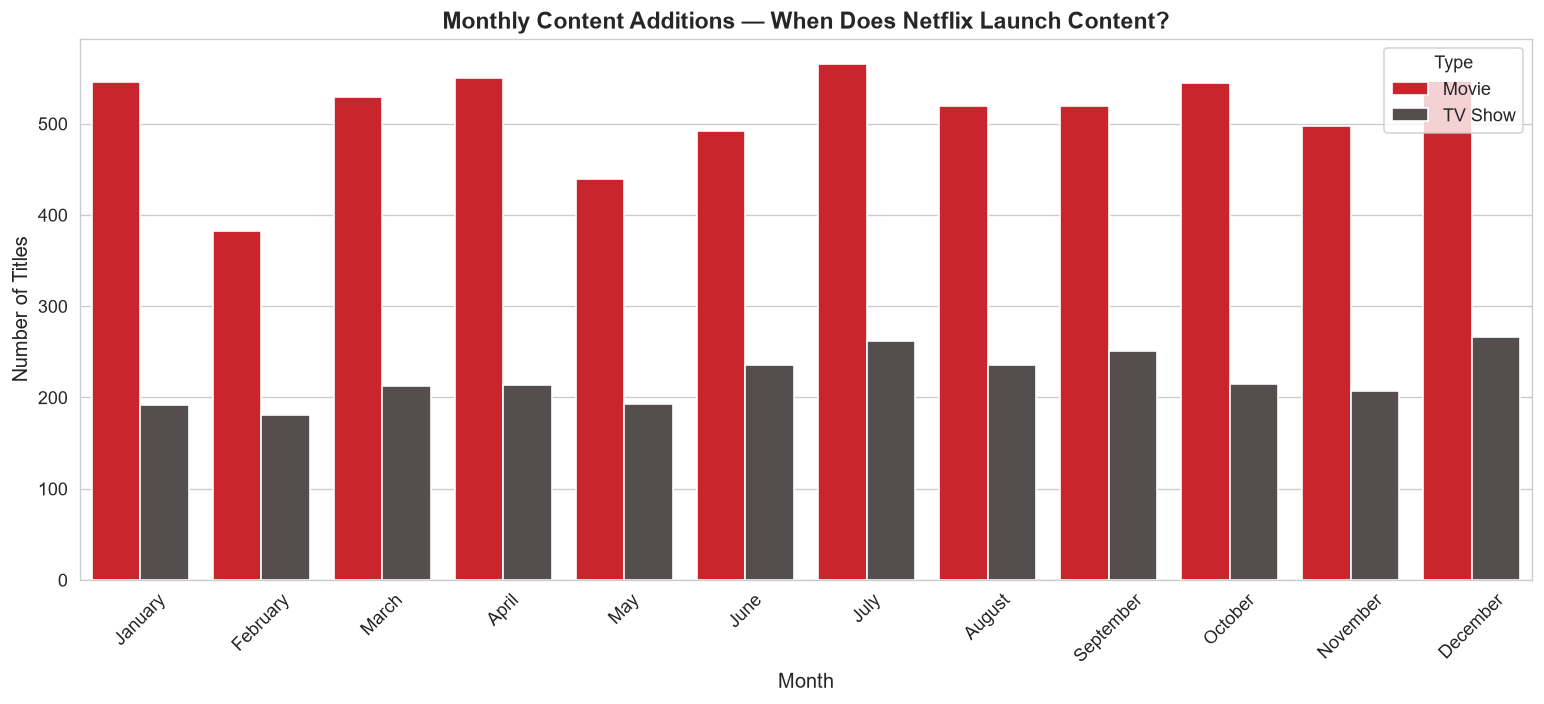

In [26]:
# ── 4.2.4 Monthly Content Additions — Best Time to Launch ───────────────
monthly = df.dropna(subset=["month_added"]).copy()
monthly["month_added"] = monthly["month_added"].astype(int)
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

fig, ax = plt.subplots(figsize=(13, 6))
sns.countplot(data=monthly, x="month_name", order=month_order,
              hue="type", palette=[NETFLIX_RED, "#564d4d"], ax=ax)
ax.set_title("Monthly Content Additions — When Does Netflix Launch Content?", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Titles")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Type")
fig.tight_layout()
save_fig(fig, "10_monthly_content_additions.png")

---
<a id="5"></a>
## 5. Missing Value & Outlier Check (10 pts)

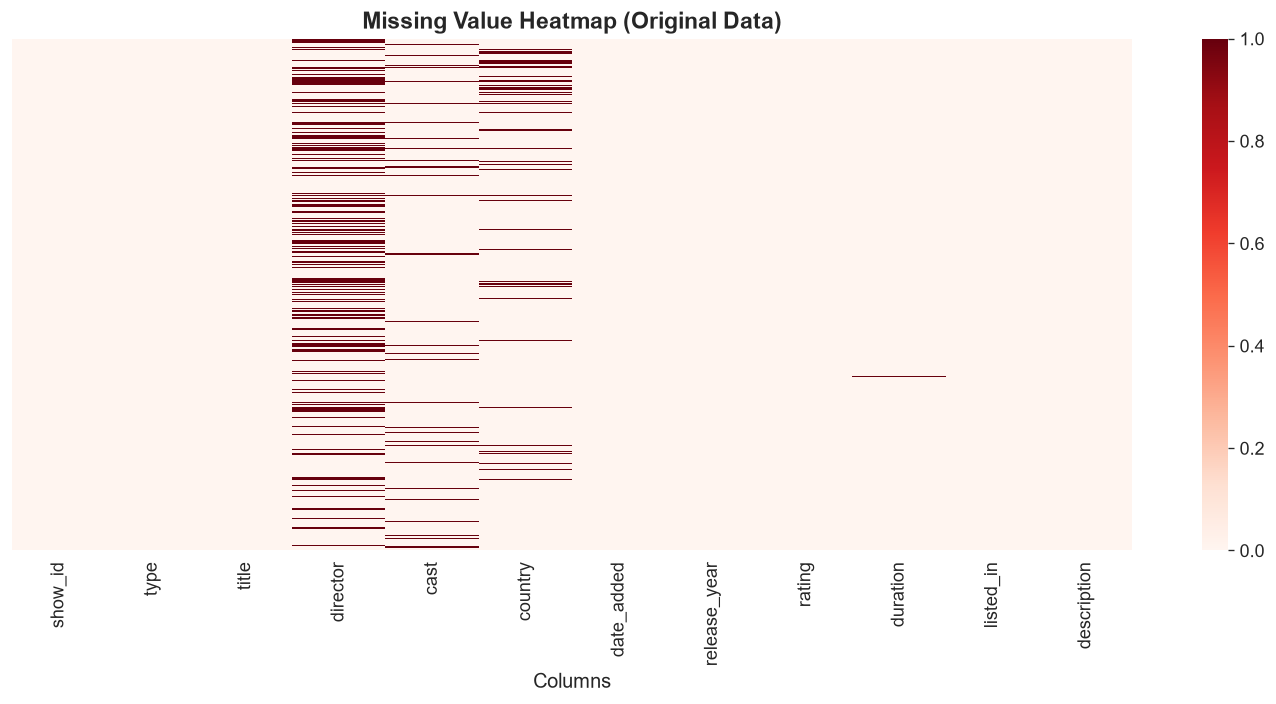

In [27]:
# ── 5.1 Missing Value Heatmap ───────────────────────────────────────────
# Reload the raw data to show the original missing pattern
df_raw = pd.read_csv(DATA_PATH)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(df_raw.isnull(), cbar=True, cmap="Reds", yticklabels=False, ax=ax)
ax.set_title("Missing Value Heatmap (Original Data)", fontweight="bold")
ax.set_xlabel("Columns")
fig.tight_layout()
save_fig(fig, "11_missing_value_heatmap.png")

In [28]:
# Missing value summary (original data)
print("Missing Value Summary (Before Imputation):\n")
raw_missing = df_raw.isnull().sum()
raw_pct = (raw_missing / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({"Missing": raw_missing, "% Missing": raw_pct})
print(missing_summary[missing_summary["Missing"] > 0].sort_values("% Missing", ascending=False).to_string())

Missing Value Summary (Before Imputation):

            Missing  % Missing
director       2634      29.91
country         831       9.44
cast            825       9.37
date_added       10       0.11
rating            4       0.05
duration          3       0.03


Release Year — Q1: 2013.0, Q3: 2019.0, IQR: 6.0
Lower Bound: 2004.0, Upper Bound: 2028.0
Number of Outliers: 719

Movie Duration — Q1: 87.0, Q3: 114.0, IQR: 27.0
Lower Bound: 46.5, Upper Bound: 154.5
Number of Outliers: 450


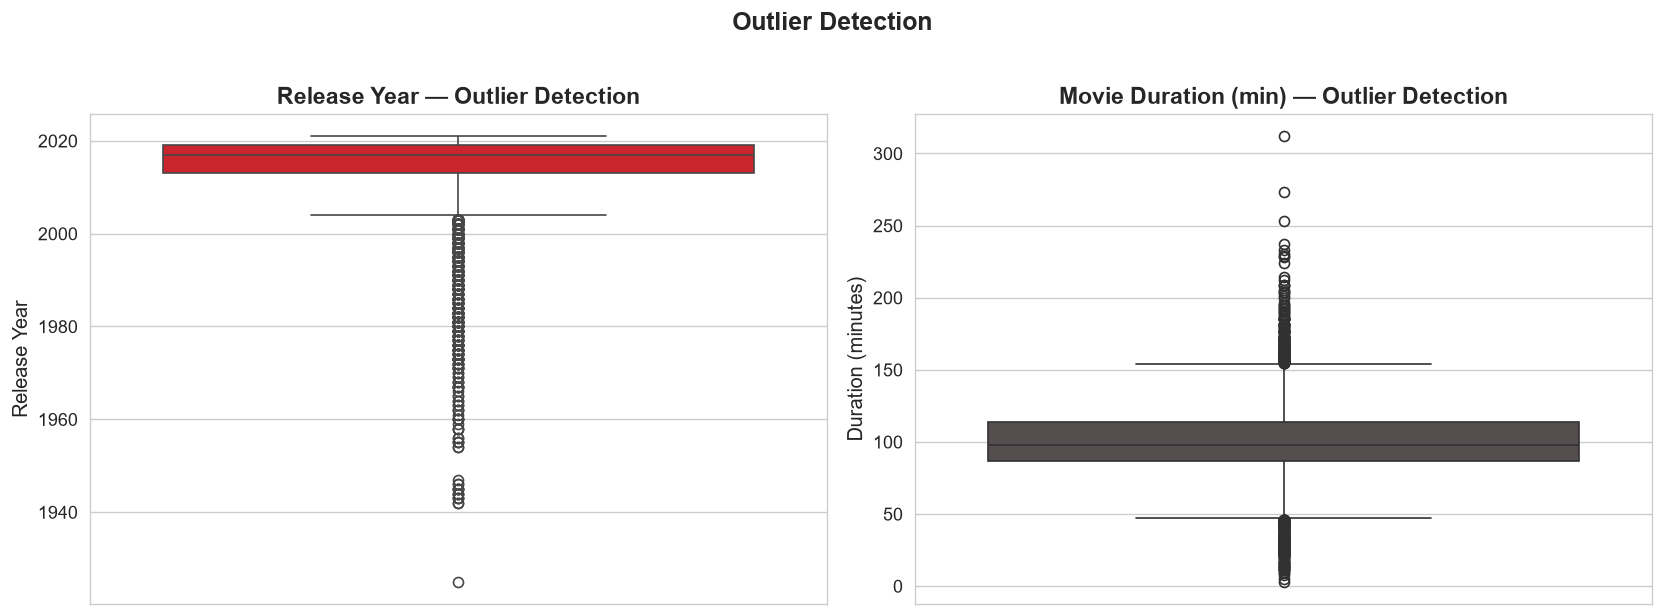

In [29]:
# ── 5.2 Outlier Detection — Release Year ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df["release_year"], color=NETFLIX_RED, ax=axes[0])
axes[0].set_title("Release Year — Outlier Detection", fontweight="bold")
axes[0].set_ylabel("Release Year")

# IQR stats
Q1 = df["release_year"].quantile(0.25)
Q3 = df["release_year"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_year = df[(df["release_year"] < lower_bound) | (df["release_year"] > upper_bound)]
print(f"Release Year — Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print(f"Number of Outliers: {len(outliers_year)}")

# ── Outlier Detection — Duration (Movies) ────────────────────────────────
sns.boxplot(y=movies["duration_int"], color="#564d4d", ax=axes[1])
axes[1].set_title("Movie Duration (min) — Outlier Detection", fontweight="bold")
axes[1].set_ylabel("Duration (minutes)")

Q1_d = movies["duration_int"].quantile(0.25)
Q3_d = movies["duration_int"].quantile(0.75)
IQR_d = Q3_d - Q1_d
lower_d = Q1_d - 1.5 * IQR_d
upper_d = Q3_d + 1.5 * IQR_d
outliers_dur = movies[(movies["duration_int"] < lower_d) | (movies["duration_int"] > upper_d)]
print(f"\nMovie Duration — Q1: {Q1_d}, Q3: {Q3_d}, IQR: {IQR_d}")
print(f"Lower Bound: {lower_d}, Upper Bound: {upper_d}")
print(f"Number of Outliers: {len(outliers_dur)}")

fig.suptitle("Outlier Detection", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig(fig, "12_outlier_detection.png")

In [30]:
# Outlier titles (very old content or very long movies)
if len(outliers_year) > 0:
    print("Sample Outliers — Release Year:")
    print(outliers_year[["title", "type", "release_year"]].head(10).to_string(index=False))

if len(outliers_dur) > 0:
    print("\nSample Outliers — Movie Duration (extremely short or long):")
    print(outliers_dur[["title", "duration", "duration_int"]].sort_values("duration_int", ascending=False).head(10).to_string(index=False))

Sample Outliers — Release Year:
                                                    title  type  release_year
                                                  Sankofa Movie          1993
                                          Avvai Shanmughi Movie          1996
                                                    Jeans Movie          1998
                                           Minsara Kanavu Movie          1997
                                                     Jaws Movie          1975
                                                   Jaws 2 Movie          1978
                                                   Jaws 3 Movie          1983
                                        Jaws: The Revenge Movie          1987
                                             Training Day Movie          2001
InuYasha the Movie 2: The Castle Beyond the Looking Glass Movie          2002

Sample Outliers — Movie Duration (extremely short or long):
                      title duration  duration_in

---
<a id="6"></a>
## 6. Insights (10 pts)

### 6.1 Range of Attributes & Distribution Comments

In [31]:
print("=" * 60)
print("ATTRIBUTE RANGES & DISTRIBUTION SUMMARY")
print("=" * 60)

print(f"\n📌 Release Year Range : {df['release_year'].min()} – {df['release_year'].max()}")
print(f"📌 Movie Duration     : {movies['duration_int'].min():.0f} – {movies['duration_int'].max():.0f} minutes")
print(f"📌 TV Show Seasons    : {tv['duration_int'].min():.0f} – {tv['duration_int'].max():.0f} seasons")
print(f"📌 Unique Countries   : {df_countries['country_single'].nunique()}")
print(f"📌 Unique Genres      : {df_genres['genre'].nunique()}")
print(f"📌 Unique Directors   : {df_directors[df_directors['dir_name'] != 'Unknown']['dir_name'].nunique()}")
print(f"📌 Unique Actors      : {df_cast[df_cast['actor'] != 'Unknown']['actor'].nunique()}")

ATTRIBUTE RANGES & DISTRIBUTION SUMMARY

📌 Release Year Range : 1925 – 2021
📌 Movie Duration     : 3 – 312 minutes
📌 TV Show Seasons    : 1 – 17 seasons
📌 Unique Countries   : 128
📌 Unique Genres      : 42
📌 Unique Directors   : 4993
📌 Unique Actors      : 36439


### 6.2 Plot-by-Plot Commentary

| # | Chart | Key Observation |
|---|-------|----------------|
| 1 | Content Type Split | Movies dominate (~70%), but TV Shows are a growing segment |
| 2 | Rating Distribution | TV-MA is the most common rating → Netflix skews toward adult audiences |
| 3 | Release Year Histogram | Massive spike post-2015; Netflix's aggressive content acquisition strategy |
| 4 | Top 15 Genres | International Movies, Dramas, and Comedies lead the catalog |
| 5 | Top 15 Countries | USA dominates, followed by India and the UK |
| 6 | Duration Distribution | Most movies are 80-120 min; most TV shows are 1 season |
| 7 | Release Year by Type | TV Shows on Netflix tend to be more recent than Movies |
| 8 | Duration Boxplot | Movie durations are tightly clustered; TV shows vary widely |
| 9 | Content Added Trend | Peak additions around 2019-2020; decline may reflect pandemic impact |
| 10 | Monthly Additions | July, October, December see the highest additions — aligning with vacation/holiday seasons |

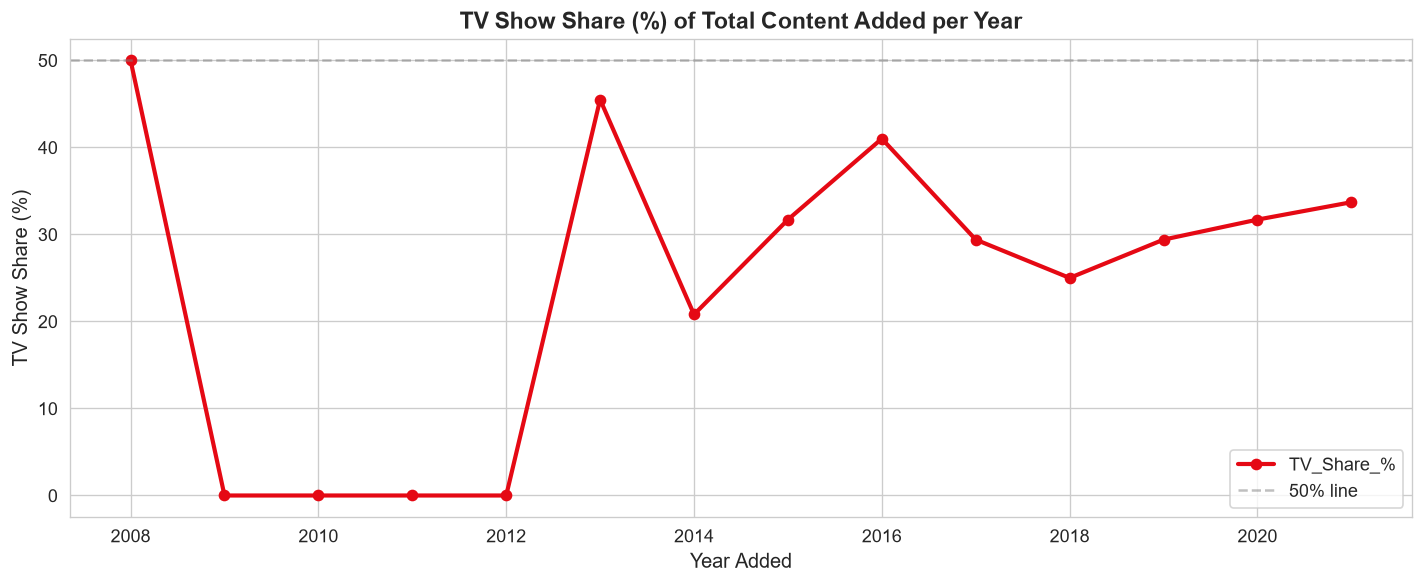


TV Show share has been increasing, indicating Netflix's strategic shift:
year_added
2014    20.8
2015    31.7
2016    41.0
2017    29.4
2018    25.0
2019    29.4
2020    31.7
2021    33.7


In [32]:
# ── 6.3 Movies vs TV Shows Trends ───────────────────────────────────────
yearly_type = df.dropna(subset=["year_added"]).groupby(["year_added", "type"]).size().unstack(fill_value=0)
yearly_type["TV_Share_%"] = (yearly_type.get("TV Show", 0) / yearly_type.sum(axis=1) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
yearly_type["TV_Share_%"].plot(marker="o", color=NETFLIX_RED, linewidth=2.5, ax=ax)
ax.set_title("TV Show Share (%) of Total Content Added per Year", fontweight="bold")
ax.set_xlabel("Year Added")
ax.set_ylabel("TV Show Share (%)")
ax.axhline(50, color="gray", linestyle="--", alpha=0.5, label="50% line")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
save_fig(fig, "13_tv_show_share_trend.png")

print("\nTV Show share has been increasing, indicating Netflix's strategic shift:")
print(yearly_type["TV_Share_%"].tail(8).to_string())

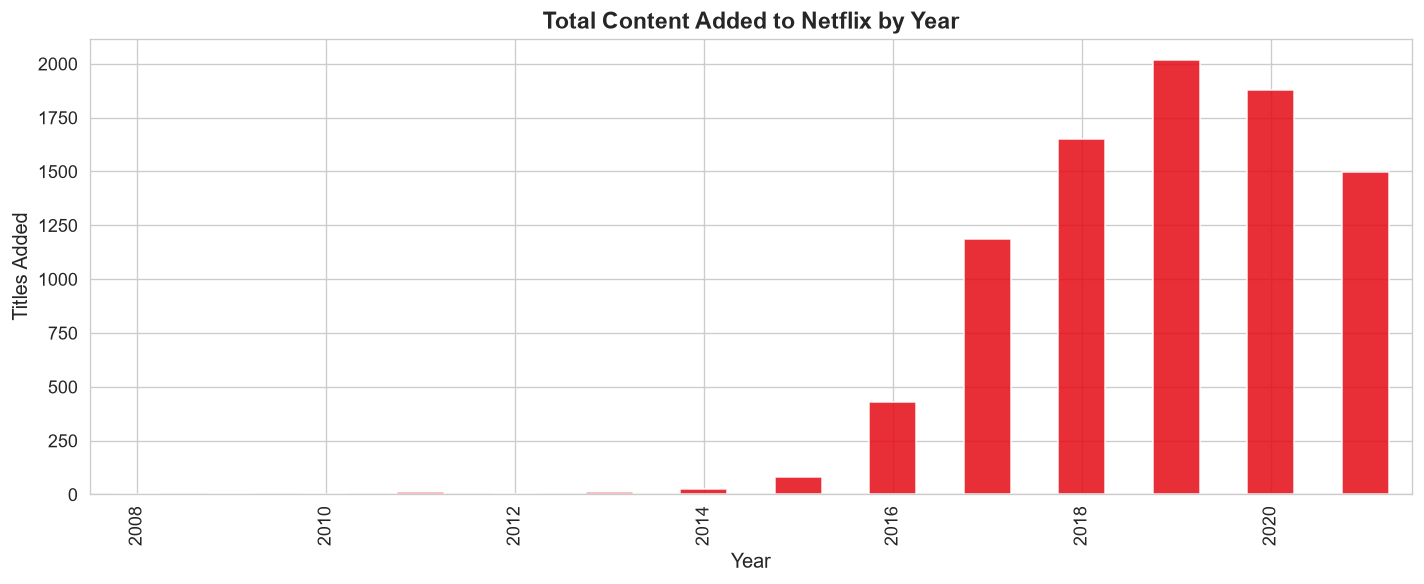

In [33]:
# ── 6.4 Content Growth Over Years ────────────────────────────────────────
yearly_total = df.dropna(subset=["year_added"]).groupby("year_added").size()

fig, ax = plt.subplots(figsize=(12, 5))
yearly_total.plot(kind="bar", color=NETFLIX_RED, edgecolor="white", ax=ax, alpha=0.85)
ax.set_title("Total Content Added to Netflix by Year", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Titles Added")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
save_fig(fig, "14_content_growth_by_year.png")

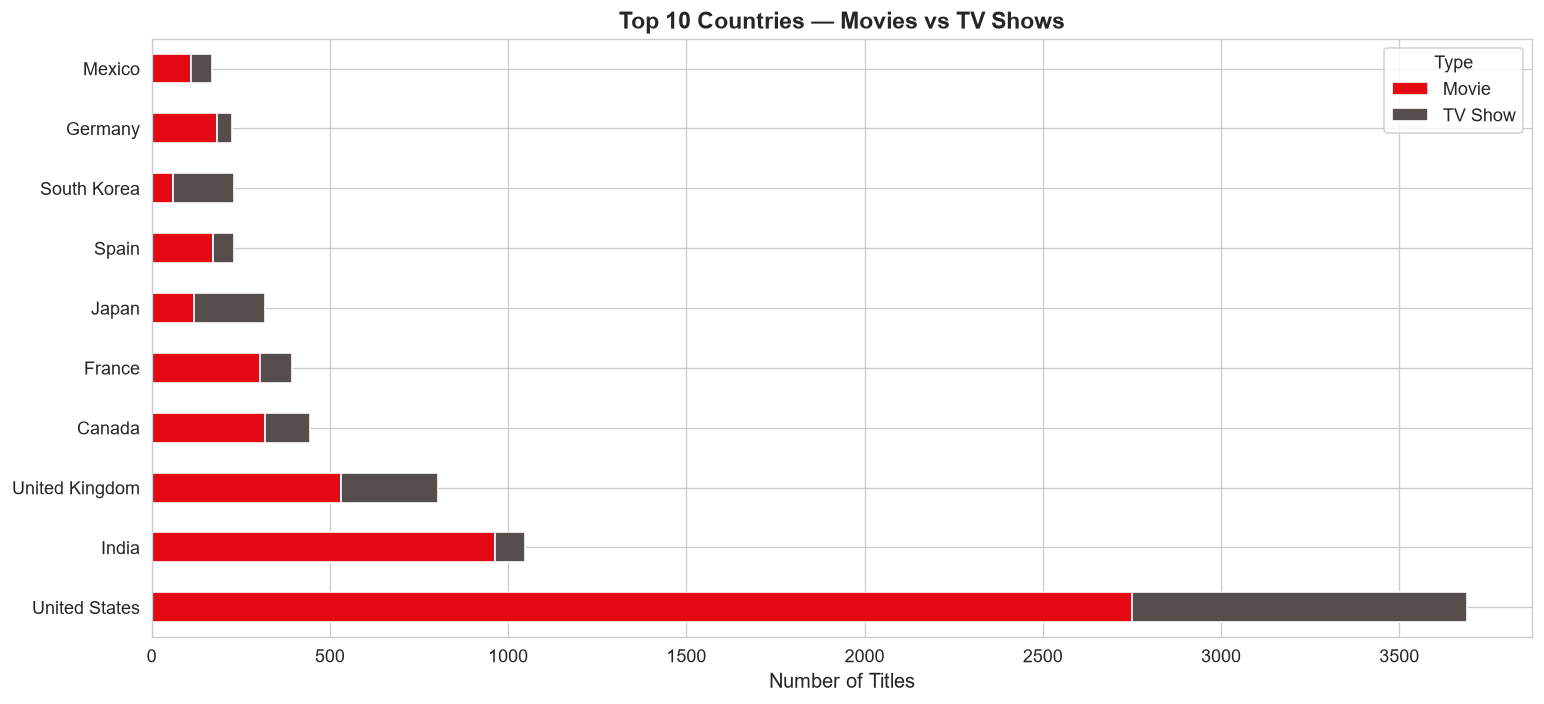

In [34]:
# ── 6.5 Content by Country — Top 10 split by type ───────────────────────
top10_countries = df_countries[df_countries["country_single"] != "Unknown"]["country_single"].value_counts().head(10).index
df_top10 = df_countries[df_countries["country_single"].isin(top10_countries)].copy()

fig, ax = plt.subplots(figsize=(13, 6))
ct = df_top10.groupby(["country_single", "type"]).size().unstack(fill_value=0)
ct = ct.reindex(top10_countries)
ct.plot(kind="barh", stacked=True, color=[NETFLIX_RED, "#564d4d"], ax=ax)
ax.set_title("Top 10 Countries — Movies vs TV Shows", fontweight="bold")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("")
ax.legend(title="Type")
fig.tight_layout()
save_fig(fig, "15_country_content_split.png")

---
<a id="7"></a>
## 7. Business Insights (10 pts)

### Key Findings

**Insight 1 — Movies Dominate, but TV Shows Are Rising**

Netflix's catalog is ~70% movies and ~30% TV shows. However, the share of
TV shows in new additions has been steadily climbing year over year, reflecting
a strategic pivot toward serialized content that drives higher engagement and
longer subscription retention.

**Insight 2 — US Content Leads, but International Markets Are Key**

The United States produces the most content on Netflix, followed by India and
the United Kingdom. However, the significant representation of countries like
South Korea, Japan, and Spain indicates Netflix's global content strategy is
already bearing fruit — especially with K-Drama and anime segments.

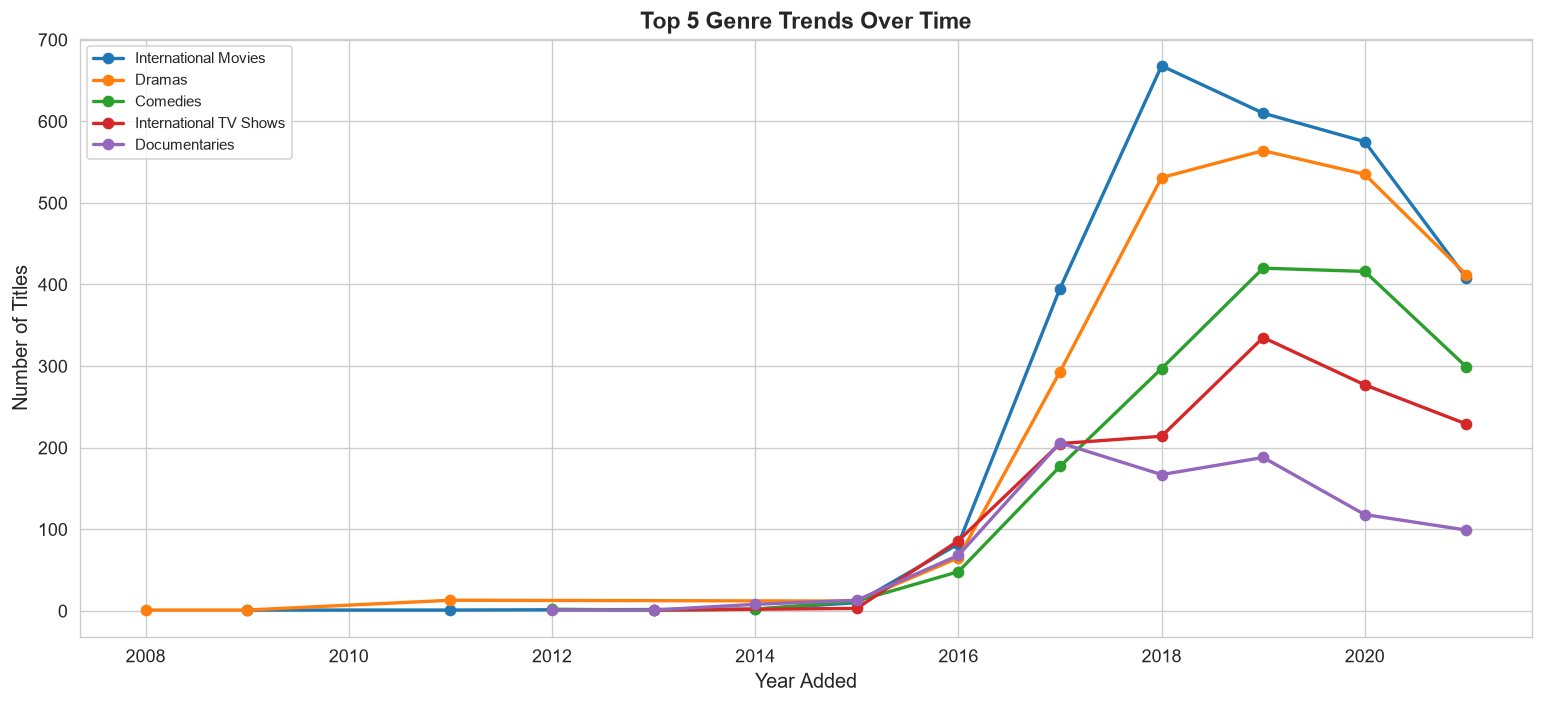

In [35]:
# ── Genre Trends over time ──────────────────────────────────────────────
df_genre_year = df.dropna(subset=["year_added"]).copy()
df_genre_year["year_added"] = df_genre_year["year_added"].astype(int)
df_genre_year = df_genre_year[["show_id", "year_added", "listed_in"]].assign(
    genre=df_genre_year["listed_in"].str.split(", ")
).explode("genre")
df_genre_year["genre"] = df_genre_year["genre"].str.strip()

top5_genres = df_genre_year["genre"].value_counts().head(5).index
genre_trend = df_genre_year[df_genre_year["genre"].isin(top5_genres)].groupby(
    ["year_added", "genre"]
).size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(13, 6))
for genre in top5_genres:
    subset = genre_trend[genre_trend["genre"] == genre]
    ax.plot(subset["year_added"], subset["count"], marker="o", linewidth=2, label=genre)
ax.set_title("Top 5 Genre Trends Over Time", fontweight="bold")
ax.set_xlabel("Year Added")
ax.set_ylabel("Number of Titles")
ax.legend(fontsize=9, loc="upper left")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
save_fig(fig, "16_genre_trends.png")

**Insight 3 — Genre Trends**

International Movies and Dramas have seen the largest growth. The rise of
International content signals Netflix's commitment to non-English programming.
Comedies and Documentaries remain steady performers.

**Insight 4 — Best Time to Launch Content**

The monthly analysis reveals that **July, October, November, and December** are
the peak months for new content additions. This aligns with:
- **Summer break** (July) → Families and students have more viewing time
- **Year-end holidays** (Oct–Dec) → Festive season binge-watching

Launching tentpole titles during these windows maximizes engagement.

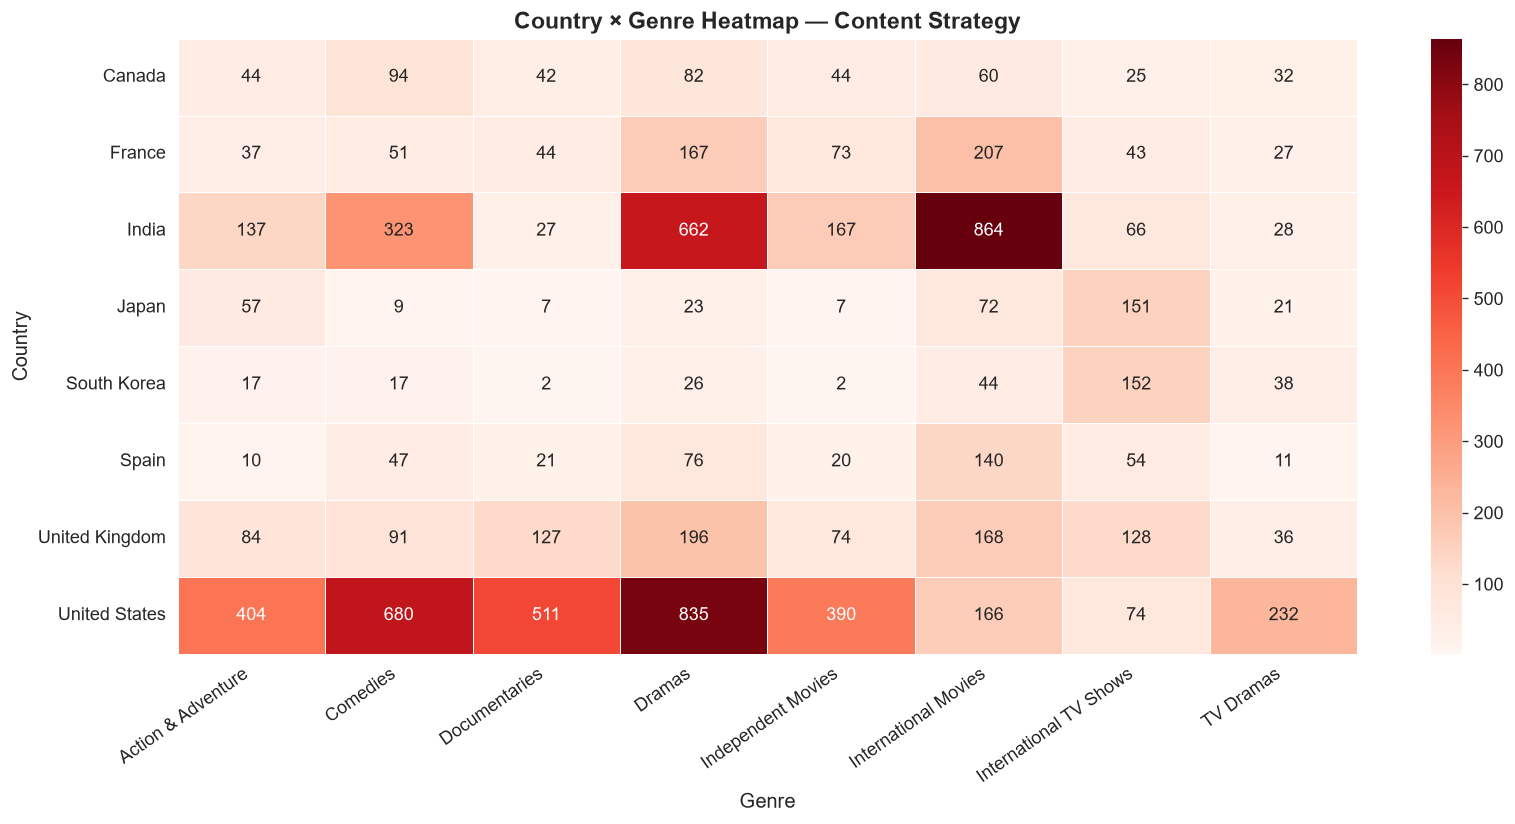

In [36]:
# ── Country-wise content strategy — Heatmap ─────────────────────────────
top8_countries = df_countries[df_countries["country_single"] != "Unknown"]["country_single"].value_counts().head(8).index
top8_genres = df_genres["genre"].value_counts().head(8).index

df_cg = df.dropna(subset=["country"]).copy()
df_cg = df_cg.assign(country_single=df_cg["country"].str.split(", ")).explode("country_single")
df_cg["country_single"] = df_cg["country_single"].str.strip()
df_cg = df_cg.assign(genre=df_cg["listed_in"].str.split(", ")).explode("genre")
df_cg["genre"] = df_cg["genre"].str.strip()

pivot = df_cg[df_cg["country_single"].isin(top8_countries) & df_cg["genre"].isin(top8_genres)].pivot_table(
    index="country_single", columns="genre", aggfunc="size", fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Reds", linewidths=0.5, ax=ax)
ax.set_title("Country × Genre Heatmap — Content Strategy", fontweight="bold")
ax.set_ylabel("Country")
ax.set_xlabel("Genre")
plt.xticks(rotation=35, ha="right")
fig.tight_layout()
save_fig(fig, "17_country_genre_heatmap.png")

---
<a id="8"></a>
## 8. Recommendations (10 pts)

Based on the analysis above, here are **actionable recommendations** for
Netflix's content strategy:

### 🎯 Recommendation 1 — Increase TV Show Production
TV shows drive higher subscriber retention because viewers return week after
week (or binge entire seasons). The data shows Netflix is already shifting in
this direction. **Accelerate investment in multi-season original TV shows**,
especially in proven genres like Dramas, Crime, and Sci-Fi.

### 🌍 Recommendation 2 — Focus on Underserved Markets
While the US, India, and UK are well-covered, markets like **South America,
Southeast Asia, and Africa** present growth opportunities. Producing localized
content in these regions can drive subscriber growth. For example, the success
of Korean dramas (Squid Game) shows the appetite for non-English content.

### 📅 Recommendation 3 — Align Launches with Seasonal Patterns
Schedule **flagship releases in July (summer break)** and the **October–December
holiday window**. Spread smaller titles in the traditionally quiet months
(February, April) to maintain a steady content flow.

### 🎭 Recommendation 4 — Double Down on International Content
"International Movies" and "International TV Shows" are among the fastest-growing
genres. Invest in dubbing and subtitling infrastructure to make this content
accessible globally. This is a cost-effective way to fill the catalog while
building goodwill in local markets.

### ⏱️ Recommendation 5 — Optimize Movie Lengths
The majority of movies fall in the 80–120 minute range. Avoid producing
excessively long films (>150 min) unless the content warrants it (e.g., epic
dramas or documentaries). Shorter, sharper content performs better in the
streaming era.

### 📊 Recommendation 6 — Curate Ratings for Target Demographics
TV-MA content dominates the platform. To expand the family and kids segment,
**increase production of TV-Y, TV-G, and PG-rated content**. This opens up a
new subscriber demographic (parents) and increases household penetration.

In [37]:
# ── Summary statistics for the report ───────────────────────────────────
print("=" * 60)
print("📋  NETFLIX EDA — EXECUTIVE SUMMARY")
print("=" * 60)
print(f"  Total titles analyzed        : {len(df):,}")
print(f"  Movies                       : {(df['type']=='Movie').sum():,} ({(df['type']=='Movie').mean()*100:.1f}%)")
print(f"  TV Shows                     : {(df['type']=='TV Show').sum():,} ({(df['type']=='TV Show').mean()*100:.1f}%)")
print(f"  Unique countries             : {df_countries['country_single'].nunique()}")
print(f"  Unique genres                : {df_genres['genre'].nunique()}")
print(f"  Median movie duration        : {movies['duration_int'].median():.0f} minutes")
print(f"  Median TV show duration      : {tv['duration_int'].median():.0f} season(s)")
print(f"  Most common rating           : {df['rating'].value_counts().index[0]}")
print(f"  Peak year for additions      : {yearly_total.idxmax():.0f} ({yearly_total.max():,} titles)")
print(f"  Charts saved to              : {IMG_DIR}/")
print("=" * 60)

📋  NETFLIX EDA — EXECUTIVE SUMMARY
  Total titles analyzed        : 8,807
  Movies                       : 6,131 (69.6%)
  TV Shows                     : 2,676 (30.4%)
  Unique countries             : 128
  Unique genres                : 42
  Median movie duration        : 98 minutes
  Median TV show duration      : 1 season(s)
  Most common rating           : TV-MA
  Peak year for additions      : 2019 (2,016 titles)
  Charts saved to              : images/


---

### 📁 All charts saved to `images/` directory

| # | File | Description |
|---|------|-------------|
| 1 | `01_content_type_distribution.png` | Movie vs TV Show split |
| 2 | `02_rating_distribution.png` | Content rating counts |
| 3 | `03_release_year_histogram.png` | Distribution of release years |
| 4 | `04_top15_genres.png` | Top 15 genres |
| 5 | `05_top15_countries.png` | Top 15 content-producing countries |
| 6 | `06_duration_distribution.png` | Duration histograms |
| 7 | `07_release_year_by_type_boxplot.png` | Release year boxplot by type |
| 8 | `08_duration_by_type_boxplot.png` | Duration boxplot by type |
| 9 | `09_content_added_per_year.png` | Yearly content addition trend |
| 10 | `10_monthly_content_additions.png` | Monthly content additions |
| 11 | `11_missing_value_heatmap.png` | Missing value heatmap |
| 12 | `12_outlier_detection.png` | Outlier boxplots |
| 13 | `13_tv_show_share_trend.png` | TV show share % over time |
| 14 | `14_content_growth_by_year.png` | Total content growth by year |
| 15 | `15_country_content_split.png` | Top 10 countries — type split |
| 16 | `16_genre_trends.png` | Top 5 genre trends |
| 17 | `17_country_genre_heatmap.png` | Country × Genre heatmap |

---
**End of Analysis** | *Pritam Palit*